### Individual Homework

#### Enter your name here:

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

**Analysis of movies IMDB dataset**

We will look at a ***subset*** sample of movies, taken from the [Kaggle IMDB 5000 movie dataset](https://www.kaggle.com/carolzhangdc/imdb-5000-movie-dataset)

In [36]:
movies = pd.read_csv('../Data/movies.csv')
movies

,title,genre,director,year,duration,gross,budget,cast_facebook_likes,votes,reviews,rating
0,Avatar,Action,James Cameron,2009,178,760505847,237000000,4834,886204,3777,7.90
1,Titanic,Drama,James Cameron,1997,194,658672302,200000000,45223,793059,2843,7.70
2,Jurassic World,Action,Colin Trevorrow,2015,124,652177271,150000000,8458,418214,1934,7.00
3,The Avengers,Action,Joss Whedon,2012,173,623279547,220000000,87697,995415,2425,8.10
4,The Dark Knight,Action,Christopher Nolan,2008,152,533316061,185000000,57802,1676169,5312,9.00
...,...,...,...,...,...,...,...,...,...,...,...
2956,Locker 13,Thriller,Bruce Dellis,2014,95,2468,300000,2048,241,15,4.80
2957,The Ghastly Love of Johnny X,Comedy,Paul Bunnell,2012,106,2436,2000000,1611,344,113,5.70
2958,Detention of the Dead,Comedy,Alex Craig Mann,2012,87,1332,500000,2251,2038,49,4.60
2959,The Trials of Darryl Hunt,Crime,Ricki Stern,2006,106,1111,200000,2,771,21,7.70


Besides the obvious variables of `title`, `genre`, `director`, `year`, and `duration`, the rest of the variables are as follows:

-   `gross` : The gross earnings in the US box office, not adjusted for inflation
-   `budget`: The movie's budget
-   `cast_facebook_likes`: the number of facebook likes cast memebrs received
-   `votes`: the number of people who voted for (or rated) the movie in IMDB
-   `reviews`: the number of reviews for that movie
-   `rating`: IMDB average rating

**Produce a table with the count of movies by genre, ranked in descending order**


In [5]:
movie_genre_counts = movies['genre'].value_counts().sort_values(ascending=False)
display(movie_genre_counts)

genre
Comedy         848
Action         738
Drama          498
Adventure      288
Crime          202
Biography      135
Horror         131
Animation       35
Fantasy         28
Documentary     25
Mystery         16
Sci-Fi           7
Family           3
Musical          2
Romance          2
Western          2
Thriller         1
Name: count, dtype: int64

**Produce a table with the average gross earning and budget (`gross` and `budget`) by genre. Calculate a variable `return_on_budget` which shows how many \$ did a movie make at the box office for each \$ of its budget. Ranked genres by this `return_on_budget` in descending order**

In [37]:
money_movies = movies.groupby(
        'genre'
    ).agg(
        avg_gross = ('gross', 'mean'),
        avg_budget = ('budget', 'mean')
    )

money_movies['return_on_budget'] = money_movies['avg_gross'] / money_movies['avg_budget']
money_movies = money_movies.sort_values("return_on_budget", ascending=False)

display(money_movies)

,avg_gross,avg_budget,return_on_budget
genre,,,
Musical,"92,084,000.00","3,189,500.00",28.87
Family,"149,160,477.67","14,833,333.33",10.06
Western,"20,821,884.00","3,465,000.00",6.01
Documentary,"17,353,973.44","5,887,852.44",2.95
Horror,"37,713,737.60","13,504,916.11",2.79
Fantasy,"42,408,840.57","17,582,142.86",2.41
Comedy,"42,630,551.96","24,446,319.40",1.74
Mystery,"67,533,020.94","39,218,750.00",1.72
Animation,"98,433,792.17","61,701,428.57",1.60


**Produce a table that shows the top 15 directors who have created the highest gross revenue in the box office. Don't just show the total gross amount, but also the mean, median, and standard deviation per director**

In [7]:
best_directors = (movies.groupby(
            "director"
        ).agg(
            total_gross = ('gross', 'sum'),
            mean_gross = ('gross', 'mean'),
            median_gross = ('gross', 'median'),
            SD_gross = ('gross', 'std')
        ).sort_values(
            "total_gross", ascending=False
        ).iloc[0:15].reset_index()
    )

display(best_directors)

,director,total_gross,mean_gross,median_gross,SD_gross
0,Steven Spielberg,4014061704,1.745244e+08,164435221.0,1.014211e+08
1,Michael Bay,2231242537,1.716340e+08,138396624.0,1.271616e+08
2,Tim Burton,2071275480,1.294547e+08,76519172.0,1.087269e+08
3,Sam Raimi,2014600898,2.014601e+08,234903076.0,1.621266e+08
4,James Cameron,1909725910,3.182877e+08,175562880.5,3.091713e+08
5,Christopher Nolan,1813227576,2.266534e+08,196667606.5,1.872241e+08
6,George Lucas,1741418480,3.482837e+08,380262555.0,1.461939e+08
7,Robert Zemeckis,1619309108,1.245622e+08,100853835.0,9.130028e+07
8,Clint Eastwood,1378321100,7.254322e+07,46700000.0,7.548741e+07
9,Francis Lawrence,1358501971,2.717004e+08,281666058.0,1.354370e+08


**Produce a table that describes how ratings are distributed by genre. We don't want just the mean, but also, min, max, median, SD and some kind of a histogram or density graph that visually shows how ratings are distributed.**

,mean_rating,min_rating,max_rating,median_rating,SD_rating
genre,,,,,
Biography,7.114074,4.5,8.9,7.20,0.759827
Crime,6.915347,4.8,9.3,6.90,0.849356
Mystery,6.856250,4.6,8.5,6.90,0.881641
Musical,6.750000,6.3,7.2,6.75,0.636396
Drama,6.731526,2.1,8.8,6.80,0.916993
Documentary,6.660000,1.6,8.5,7.40,1.766588
Sci-Fi,6.657143,5.0,8.2,6.40,1.093705
Animation,6.651429,4.5,8.0,6.90,0.968131
Romance,6.650000,6.2,7.1,6.65,0.636396


Text(0, 0.5, '')

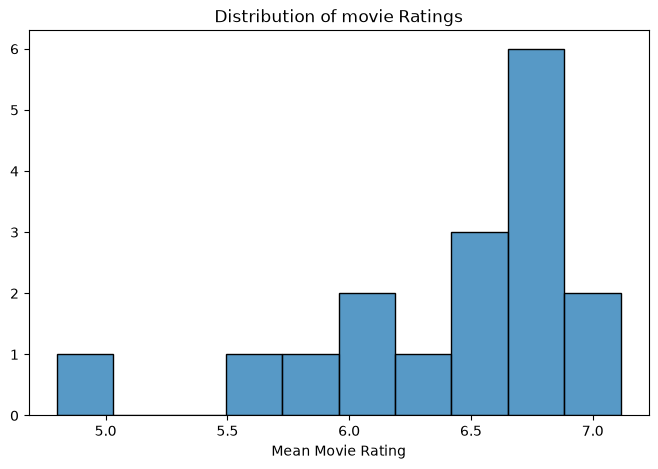

In [8]:
movie_ratings = (movies.groupby(
        "genre"
    ).agg(
        mean_rating = ('rating', 'mean'),
        min_rating = ('rating', 'min'),
        max_rating = ('rating', 'max'),
        median_rating = ('rating', 'median'),
        SD_rating = ('rating', 'std')
    ).sort_values(
        'mean_rating', ascending=False
    )
)

# here is the table
display(movie_ratings)

plt.figure(figsize=(8,5))
sns.histplot(
    data=movie_ratings, 
    x='mean_rating',
    bins = 10
)

plt.xlabel("Mean Movie Rating")
plt.title("Distribution of movie Ratings")
plt.ylabel("")


**Challenge - Produce a table of your own choosing, something you think is important/interesting to have data for, justify your result by writting a 2 sentence explanation/interpretation of the result.**

In [ ]:
genre_counts = movies['genre'].value_counts()
genres_to_keep = genre_counts[genre_counts >= 20].index

movies_filtered = movies[movies['genre'].isin(genres_to_keep)]

money_movies2 = movies_filtered.groupby(
        'genre'
    ).agg(
        avg_gross = ('gross', 'mean'),
        avg_budget = ('budget', 'mean')
    )

money_movies2['return_on_budget'] = money_movies2['avg_gross'] / money_movies2['avg_budget']
money_movies2 = money_movies2.sort_values("return_on_budget", ascending=False)

display(money_movies2)


,avg_gross,avg_budget,return_on_budget
genre,,,
Documentary,"17,353,973.44","5,887,852.44",2.95
Horror,"37,713,737.60","13,504,916.11",2.79
Fantasy,"42,408,840.57","17,582,142.86",2.41
Comedy,"42,630,551.96","24,446,319.40",1.74
Animation,"98,433,792.17","61,701,428.57",1.60
Biography,"45,201,805.19","28,543,696.32",1.58
Adventure,"95,794,257.12","66,290,069.44",1.45
Drama,"37,465,371.11","26,242,933.47",1.43
Crime,"37,502,396.74","26,596,169.14",1.41


**My Analysis**: After excluding genres with small sample sizes, the return on budget was recalculated for the remaining genres, yielding notably different results. Because these genres now have more comparable and sufficiently large sample sizes, their return on budget estimates are more representative and reliable than those in the original, unfiltered calculation.

#### Use visualisation to answer the following questions

**Examine the relationship between `gross` and `cast_facebook_likes`. Produce a scatterplot and write one sentence discussing whether the number of facebook likes that the cast has received is likely to be a good predictor of how much money a movie will make at the box office. What variable are you going to map to the Y- and X- axes?**

,gross,cast_facebook_likes
gross,1.000000,0.213161
cast_facebook_likes,0.213161,1.000000


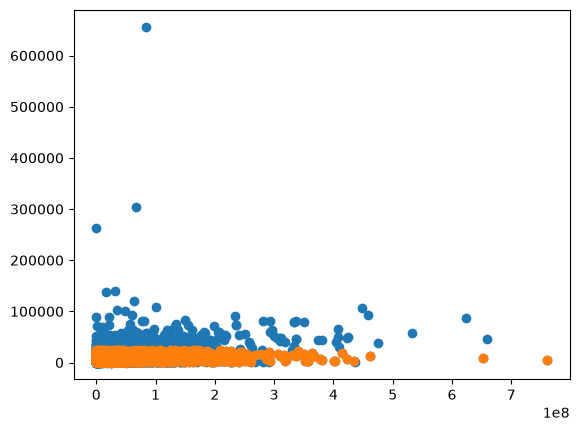

In [9]:
# preliminary exploration of the data: 
# display(movies[["gross", "cast_facebook_likes"]].head(10))

# well there seems to be a slight correlation between gross and cast_facebook_likes
display(movies[["gross", "cast_facebook_likes"]].corr())

plt.scatter(
    data = movies,
    x = "gross",
    y = "cast_facebook_likes"
)
# its hard to tell if it would make a good predictor with the amount of outliers so I will remove them before continuing 
lower = movies['cast_facebook_likes'].quantile(0.15)
upper = movies['cast_facebook_likes'].quantile(0.85)

movies_trimmed = movies[
    (movies['cast_facebook_likes'] >= lower) &
    (movies['cast_facebook_likes'] <= upper)
]

plt.scatter(
    data = movies_trimmed,
    x = "gross",
    y = "cast_facebook_likes"
)

**Answer**: Facebook likes is a poor predictor of gross income of a movie due to the large amount of outliers and the low correlation coefficient.

**Examine the relationship between `gross` and `budget`. Produce a scatterplot and write one sentence discussing whether budget is likely to be a good predictor of how much money a movie will make at the box office.**

,gross,budget
gross,1.000000,0.640834
budget,0.640834,1.000000


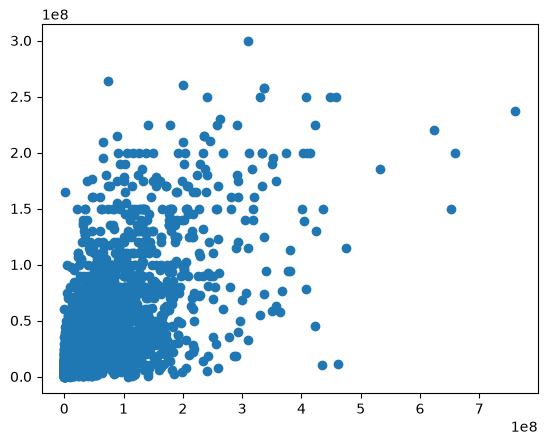

In [ ]:
display(movies[["gross", "budget"]].corr())

plt.scatter(
    data = movies,
    x = "budget",
    y = "gross"
)

plt.xlabel("")


**Answer**: Budget and gross show a strong positive correlation, indicating that a film's budget is likely to be a good predictor of its box office earnings.

**Examine the relationship between `gross` and `rating`. Produce a scatterplot, faceted by `genre` and discuss whether IMDB ratings are likely to be a good predictor of how much money a movie will make at the box office. Is there anything strange in this dataset?**

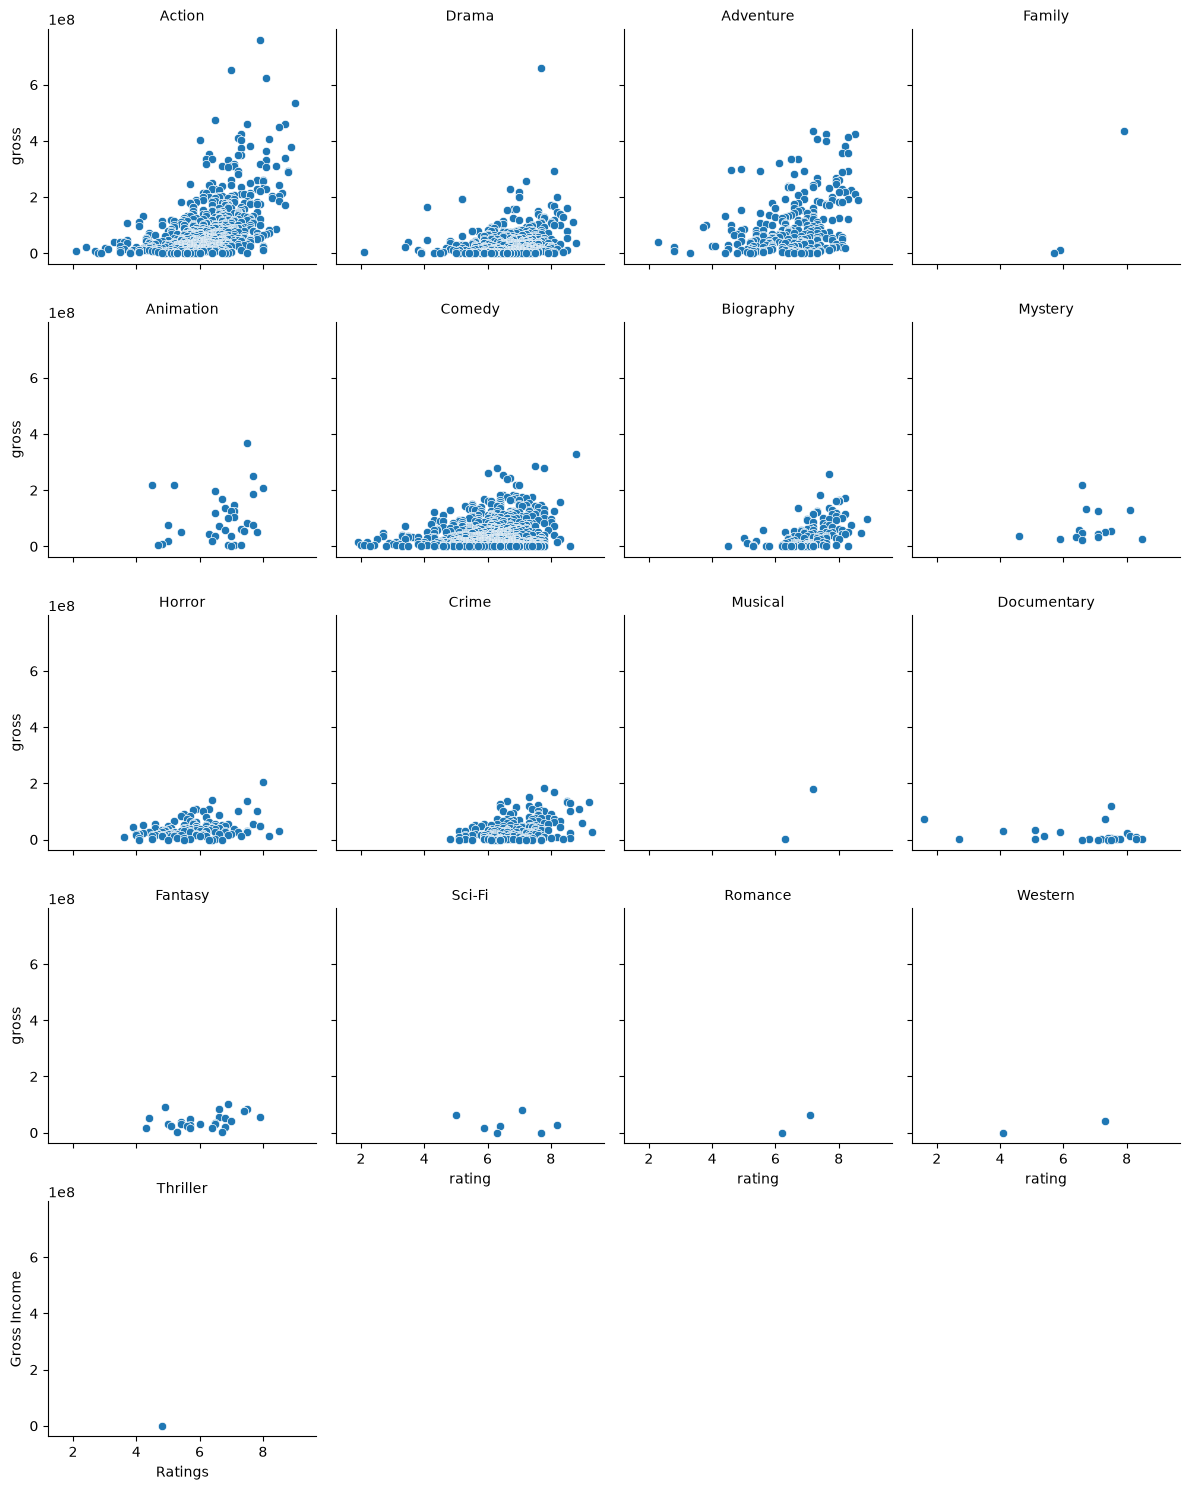

In [ ]:
# make a scatter plot 
gross_rating_plot = sns.relplot(
    data=movies,
    x='rating',
    y='gross',
    col='genre',
    col_wrap=4,
    height=3
)
gross_rating_plot.set_titles('{col_name}')
gross_rating_plot.set_axis_labels('rating', 'gross')


plt.Figure(figsize=(15, 15))
plt.xlabel("Ratings")
plt.ylabel("Gross Income")
plt.show()

**Answer**: The strength of the relationship between rating and gross varies across genres, with some genres exhibiting a stronger positive correlation than others. Genres with fewer than 10 observations were excluded from this interpretation, as correlation estimates based on such small samples are not statistically reliable.

**Challenge - Produce a visualisation of your choosing, something you think is important to explore/investigate visually. Do make it a comprehensive graph and not a single histogram or density plot. Make it publication ready, label your axes, give it a title, choose colouring options, appropirately formatted text etc.**

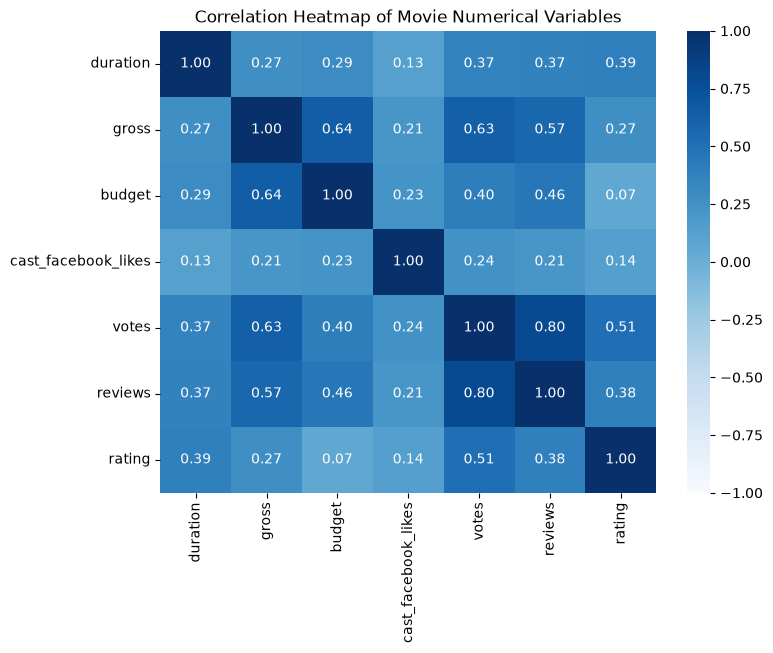

In [33]:
# make a heatmap of all the variables 
numeric_cols = ['duration', 'gross', 'budget', 'cast_facebook_likes', 'votes', 'reviews', 'rating']

corr_matrix = movies[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Movie Numerical Variables')
plt.show()

### Deliverables

Poduce a clean, stand-alone notebook (or HTML export) with:

All tables/plots properly labeled

Brief interpretations where requested

Upload final HTML/Notebook.